# Lorenz-96 demo

This notebook introduces the Lorenz-96 system and shows how to run it in Paleobeasts.
Lorenz-96 generalizes Lorenz-63 to *N* variables arranged on a periodic ring, making it a useful toy model
for multiscale dynamics and predictability experiments.

## How it differs from Lorenz-63

- **Dimension:** Lorenz-63 is 3D; Lorenz-96 is *N*-dimensional (often N=40).
- **Structure:** Lorenz-96 uses cyclic coupling on a ring: each variable interacts with its two neighbors.
- **Forcing:** Lorenz-96 is typically driven by a constant forcing term *F* (can be time-varying here).
- **Use case:** Lorenz-96 is a common testbed for data assimilation, predictability, and chaos in higher dimensions.

## How the Paleobeasts model API works

1. Create a `Forcing` object (optional for Lorenz-96 if you want time-varying F).
2. Instantiate the model.
3. Call `integrate(...)`.
4. Optionally reframe onto an evenly spaced time axis with `reframe_time_axis(...)`.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import paleobeasts as pb
from paleobeasts.signal_models import Lorenz96


In [2]:
# Common integration setup
t_span = (0.0, 30.0)
n = 10
y0 = np.ones(n)
t_eval = pb.utils.define_t_eval(t_span, delta_t=0.02)


## Unforced (constant F) Lorenz-96

Here we use the classic constant forcing term *F=8*.
In this implementation, if `forcing=None`, the model uses the constant `F` parameter.

In [3]:
lorenz_unforced = Lorenz96(forcing=None, n=n, F=8.0)
lorenz_unforced.integrate(t_span=t_span, y0=y0.tolist(), method='RK45')
lorenz_unforced.reframe_time_axis(t_eval, update_state=True)

t_u = lorenz_unforced.time
x0_u = lorenz_unforced.state_variables['x0']
x1_u = lorenz_unforced.state_variables['x1']


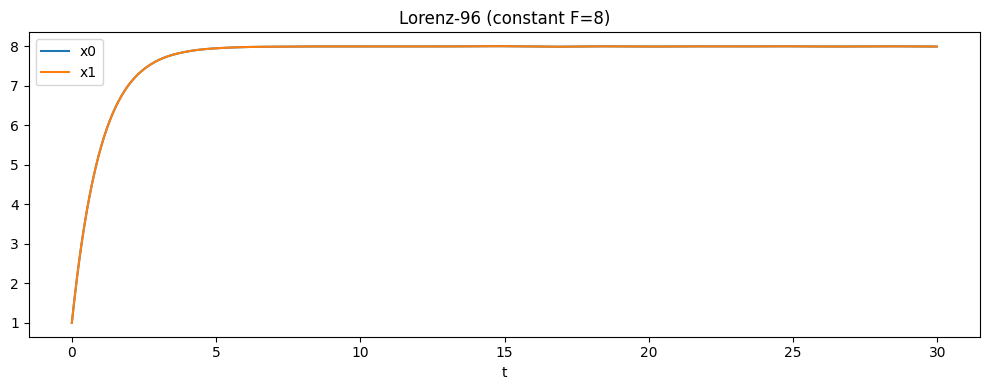

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(t_u, x0_u, label='x0')
plt.plot(t_u, x1_u, label='x1')
plt.title('Lorenz-96 (constant F=8)')
plt.xlabel('t')
plt.legend()
plt.tight_layout()


## Time-varying forcing

If you want to modulate the forcing, pass a `Forcing` object that returns `F(t)`.
Below we apply a gentle sinusoidal modulation around *F=8*.

In [5]:
def forcing_func(t):
    return 8.0 + 2.0 * np.sin(2 * np.pi * t / 10.0)

forcing = pb.core.Forcing(forcing_func)
lorenz_forced = Lorenz96(forcing=forcing, n=n, F=8.0)
lorenz_forced.integrate(t_span=t_span, y0=y0.tolist(), method='RK45')
lorenz_forced.reframe_time_axis(t_eval, update_state=True)

t_f = lorenz_forced.time
x0_f = lorenz_forced.state_variables['x0']
x1_f = lorenz_forced.state_variables['x1']


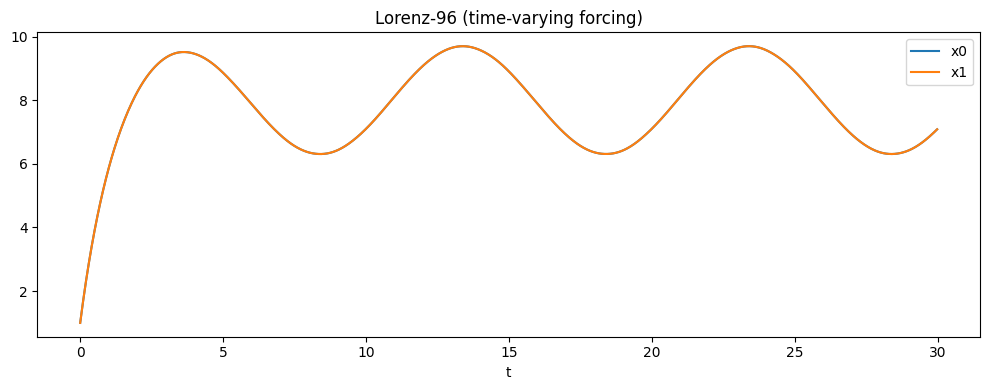

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(t_f, x0_f, label='x0')
plt.plot(t_f, x1_f, label='x1')
plt.title('Lorenz-96 (time-varying forcing)')
plt.xlabel('t')
plt.legend()
plt.tight_layout()


## Space-time visualization (forced case)

A common way to view Lorenz-96 dynamics is a space-time plot: each column is a state variable,
and each row is a time step. This highlights wave-like structures and traveling features.

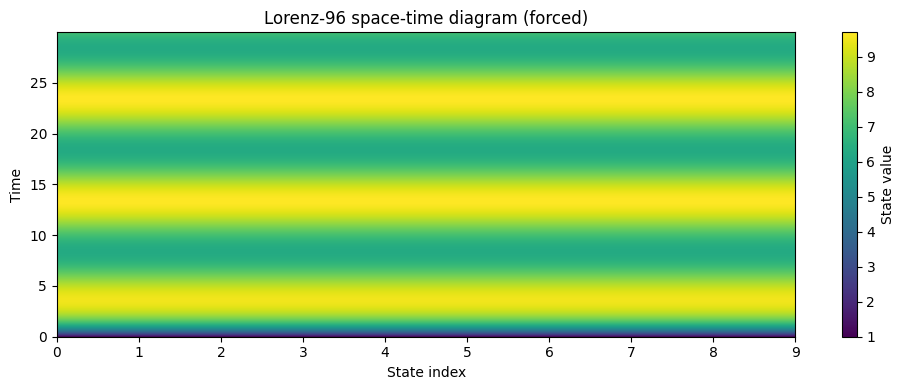

In [7]:
# Build a space-time matrix from the forced run
state_names = [f'x{i}' for i in range(n)]
X = np.column_stack([lorenz_forced.state_variables[name] for name in state_names])

plt.figure(figsize=(10, 4))
plt.imshow(X, aspect='auto', origin='lower', cmap='viridis',
           extent=[0, n - 1, t_f[0], t_f[-1]])
plt.colorbar(label='State value')
plt.title('Lorenz-96 space-time diagram (forced)')
plt.xlabel('State index')
plt.ylabel('Time')
plt.tight_layout()


## Notes and idiosyncrasies

- The state variables are named `x0, x1, ..., x{N-1}`.
- For high-dimensional runs (e.g., N=40), plotting a few coordinates is usually sufficient.
- Adaptive solvers (RK45) use uneven time steps; `reframe_time_axis(...)` gives you a uniform grid.

## Two-scale Lorenz-96

The same `Lorenz96` class handles the two-scale system: pass `J > 0` to add *J* fast variables
per slow variable. The slow equation is identical to the single-scale case with an added coupling
term; `J=0` (the default) recovers the single-scale model exactly.

**Important:** use `method='rk4'` with `kwargs={'dt': ..., 'si': ...}` when `J > 0`.
Adaptive solvers (RK45) call `dydt` at intermediate sub-steps; `method='rk4'` is PBModel's
built-in fixed-step RK4, which integrates at the fine timestep `dt` and saves output at
the coarser sampling interval `si`.

In [16]:
def s(k, K):
    """Non-dimensional coordinate in [-1, +1] for k = 0..K-1."""
    return 2 * (0.5 + k) / K - 1

K, J = 5, 5      # set J=0 for single-scale, J>0 for two-scale
nt, si, dt = 50000, 0.005, 0.005
F_2, h, b, c = 10.0, 1.0, 10.0, 10.0
t_span_2 = (0, nt * si)

k_idx = np.arange(K)
j_idx = np.arange(J * K)   # empty when J=0

X_init = s(k_idx, K) * (s(k_idx, K) - 1) * (s(k_idx, K) + 1)
Y_init = np.zeros(J * K)
y0_2 = np.concatenate([X_init, Y_init])

model_2 = Lorenz96(n=K, J=J, F=F_2, h=h, b=b, c=c, exact_rhs=True)
if J > 0:
    model_2.integrate(t_span=t_span_2, y0=y0_2,
                      method='rk4', kwargs={'dt': dt, 'si': si})
else:
    model_2.integrate(t_span=t_span_2, y0=y0_2, method='RK45')
    t_eval_2 = pb.utils.define_t_eval(t_span_2, delta_t=dt)
    model_2.reframe_time_axis(t_eval_2, update_state=True)

state_2 = model_2.state_variables
X_2 = np.column_stack([state_2[f'x{i}'] for i in range(K)])
Y_2 = np.column_stack([state_2[f'y{i}'] for i in range(K * J)]) if J > 0 else None
t_2 = np.asarray(model_2.time)

# ── Tidy dataframes for seaborn ───────────────────────────────────────────────
# Phase portrait: X_0 vs X_1, coloured by time
ik_f=2
ik_0=0
cutoff_time = 25.0
df_phase = pd.DataFrame({f'X{ik_0}': X_2[:, ik_0], f'X{ik_f}': X_2[:, ik_f], 't': t_2})
df_phase = df_phase[df_phase['t'] > cutoff_time]  # skip initial transient

# Time series: X_0 slow + all Y_{0,j} fast variables (k=0 block)
ts_rows = [pd.DataFrame({'t': t_2, 'value': X_2[:, 0], 'variable': 'X₀', 'scale': 'slow'})]
if J > 0:
    for j in range(J):
        ts_rows.append(pd.DataFrame({
            't': t_2, 'value': Y_2[:, j], 'variable': f'Y₀,{j}', 'scale': 'fast'
        }))
df_ts = pd.concat(ts_rows, ignore_index=True)
df_ts = df_ts[df_ts['t'] > cutoff_time]  # skip initial transient

X_2 = X_2[t_2 > cutoff_time, :]  # skip initial transient
Y_2 = Y_2[t_2 > cutoff_time, :] if J > 0 else None
t_2 = t_2[t_2 > cutoff_time]

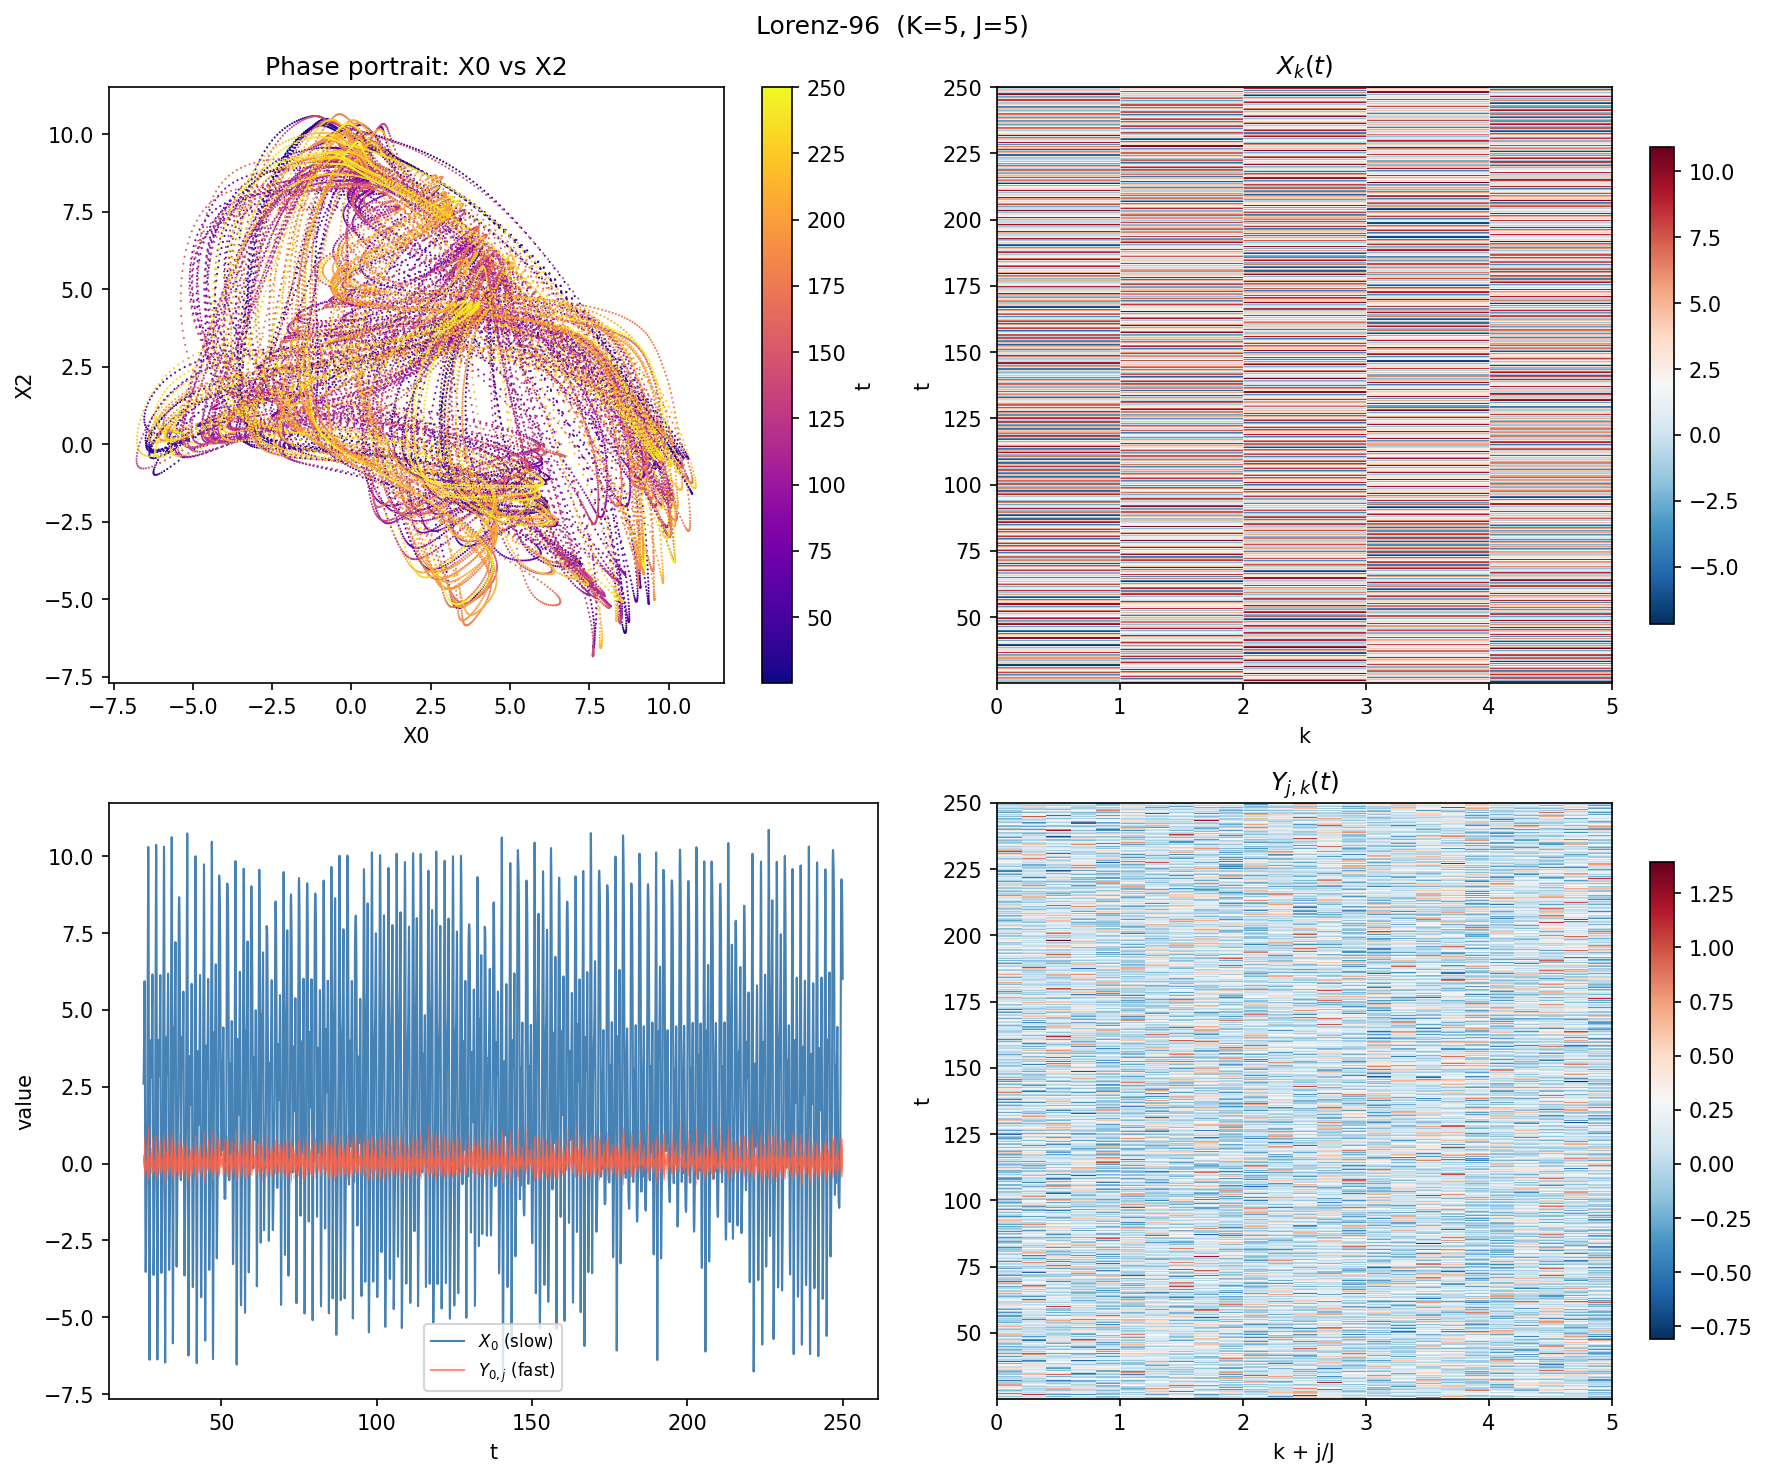

In [17]:
n_cols = 2 #if J > 0 else 1
fig, axes = plt.subplots(2, n_cols, figsize=(12, 10), dpi=150)
axes = np.array(axes).reshape(2, n_cols)

# ── Panel 1: phase portrait X₀ vs X₁, coloured by time ──────────────────────
sc = axes[0, 0].scatter(df_phase[f'X{ik_0}'], df_phase[f'X{ik_f}'],
                        c=df_phase['t'], cmap='plasma', s=1, linewidths=0)
plt.colorbar(sc, ax=axes[0, 0], label='t')
axes[0, 0].set_xlabel(f'X{ik_0}')
axes[0, 0].set_ylabel(f'X{ik_f}')
axes[0, 0].set_title(f'Phase portrait: X{ik_0} vs X{ik_f}')

# ── Panel 2: time series X₀ (slow) and Y_{0,j} (fast) ───────────────────────
slow = df_ts[df_ts['scale'] == 'slow']
sns.lineplot(data=slow, x='t', y='value', lw=1.0, color='steelblue',
             label='$X_0$ (slow)', ax=axes[1, 0])
if J > 0:
    fast = df_ts[df_ts['scale'] == 'fast']
    for _, grp in fast.groupby('variable'):
        axes[1, 0].plot(grp['t'], grp['value'], lw=0.3, alpha=0.4, color='tomato')
    axes[1, 0].plot([], [], lw=1.0, color='tomato', alpha=0.7, label='$Y_{0,j}$ (fast)')
    axes[1, 0].legend(fontsize=8)
axes[1, 0].set_xlabel('t')
axes[1, 0].set_ylabel('value')

# ── Panels 3 & 4: space-time heatmaps (J>0 only) ─────────────────────────────
if J > 0:
    panel34 = [
        (axes[0, 1], X_2, '$X_k(t)$',     'k'),
        (axes[1, 1], Y_2, '$Y_{j,k}(t)$', 'k + j/J'),
    ]
else:
    panel34 = [
        (axes[0, 1], X_2, '$X_k(t)$', 'k'),
    ]

for ax, data, title, xlabel in panel34:
    im = ax.imshow(data, aspect='auto', origin='lower',
                   extent=[0, K, t_2[0], t_2[-1]],
                   cmap='RdBu_r', interpolation='nearest')
    for k in range(1, K):
        ax.axvline(k, color='white', lw=0.5, alpha=0.6)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('t')
    ax.set_title(title)

if J ==0:
    axes[1, 1].set_visible(False)

fig.suptitle(f'Lorenz-96  (K={K}, J={J})', fontsize=12)
plt.tight_layout()
plt.show()
